# 02 — The generator: two fitted objects and a loop

The scenario generator is deliberately simple: a **sparse coefficient matrix A**
(who pushes whom, learned by lasso with at most 3 parents per equation), a
**shock pool** (history's actual surprises, kept as rows and 4-quarter blocks),
and the recursion `x_t = c + A x_{t-1} + shock`. Twenty lines of code generate;
everything else in the thesis judges and uses what gets generated.

Needs the Fed historic CSV (data/fed/...) — run from `bl225msc/`.

In [ ]:
import os, sys, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Find the folder that contains the `multistate` package (works from
# bl225msc/ or from a self-contained thesis_demo/ bundle).
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "multistate").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if (ROOT / "data" / "fed").is_dir():
    os.environ.setdefault("THESIS_DATA_DIR", str(ROOT / "data"))
RESULTS = ROOT / "results"
print(f"root: {ROOT}")

def load_csv(path, produced_by):
    path = Path(path)
    if not path.exists():
        print(f"[missing] {path}\n  produce it with:\n  {produced_by}")
        return None
    return pd.read_csv(path)

def load_pickle(path, produced_by):
    path = Path(path)
    if not path.exists():
        print(f"[missing] {path}\n  produce it with:\n  {produced_by}")
        return None
    with path.open("rb") as fh:
        return pickle.load(fh)

root: c:\Users\user\OneDrive\Desktop\thesis_clean\bl225msc\thesis_demo


In [ ]:
from multistate.scengen.macro import FEATURES, load_macro_history
from multistate.scengen.generators import default_generator_suite, edge_confidence
from multistate.scengen.suppes import SuppesPathGenerator

history = load_macro_history()
print(f"{len(history)} quarters, {history.index.min()} .. {history.index.max()}")
history.tail(3)

144 quarters, 1990Q1 .. 2025Q4


,gdp_growth,fed_funds,mortgage_30y,bbb_spread,unemployment,hpi_qoq_growth,vix
2025Q2,3.8,4.2,6.8,1.3,4.2,-0.124069,52.3
2025Q3,4.3,4.1,6.6,1.0,4.3,0.279503,20.4
2025Q4,1.0,3.7,6.2,1.0,4.5,0.154847,26.4


## The learned graph

Fit the sparse dynamics, then bootstrap edge confidence: refit on resampled
(lagged state, next state) pairs and count how often each edge survives.
An arrow means "past X helps predict Y beyond Y's own past, stably".

,parent,target,confidence,mean_coef
6,unemployment,bbb_spread,0.83,-0.068909
7,vix,fed_funds,0.81,-0.006098
8,hpi_qoq_growth,bbb_spread,0.75,-0.065650
9,hpi_qoq_growth,vix,0.74,-0.747444
10,fed_funds,bbb_spread,0.73,-0.064275
11,hpi_qoq_growth,fed_funds,0.71,0.040056
12,vix,unemployment,0.67,0.024917
13,unemployment,mortgage_30y,0.64,-0.017286
14,mortgage_30y,fed_funds,0.64,0.039116
15,unemployment,vix,0.58,-0.502277


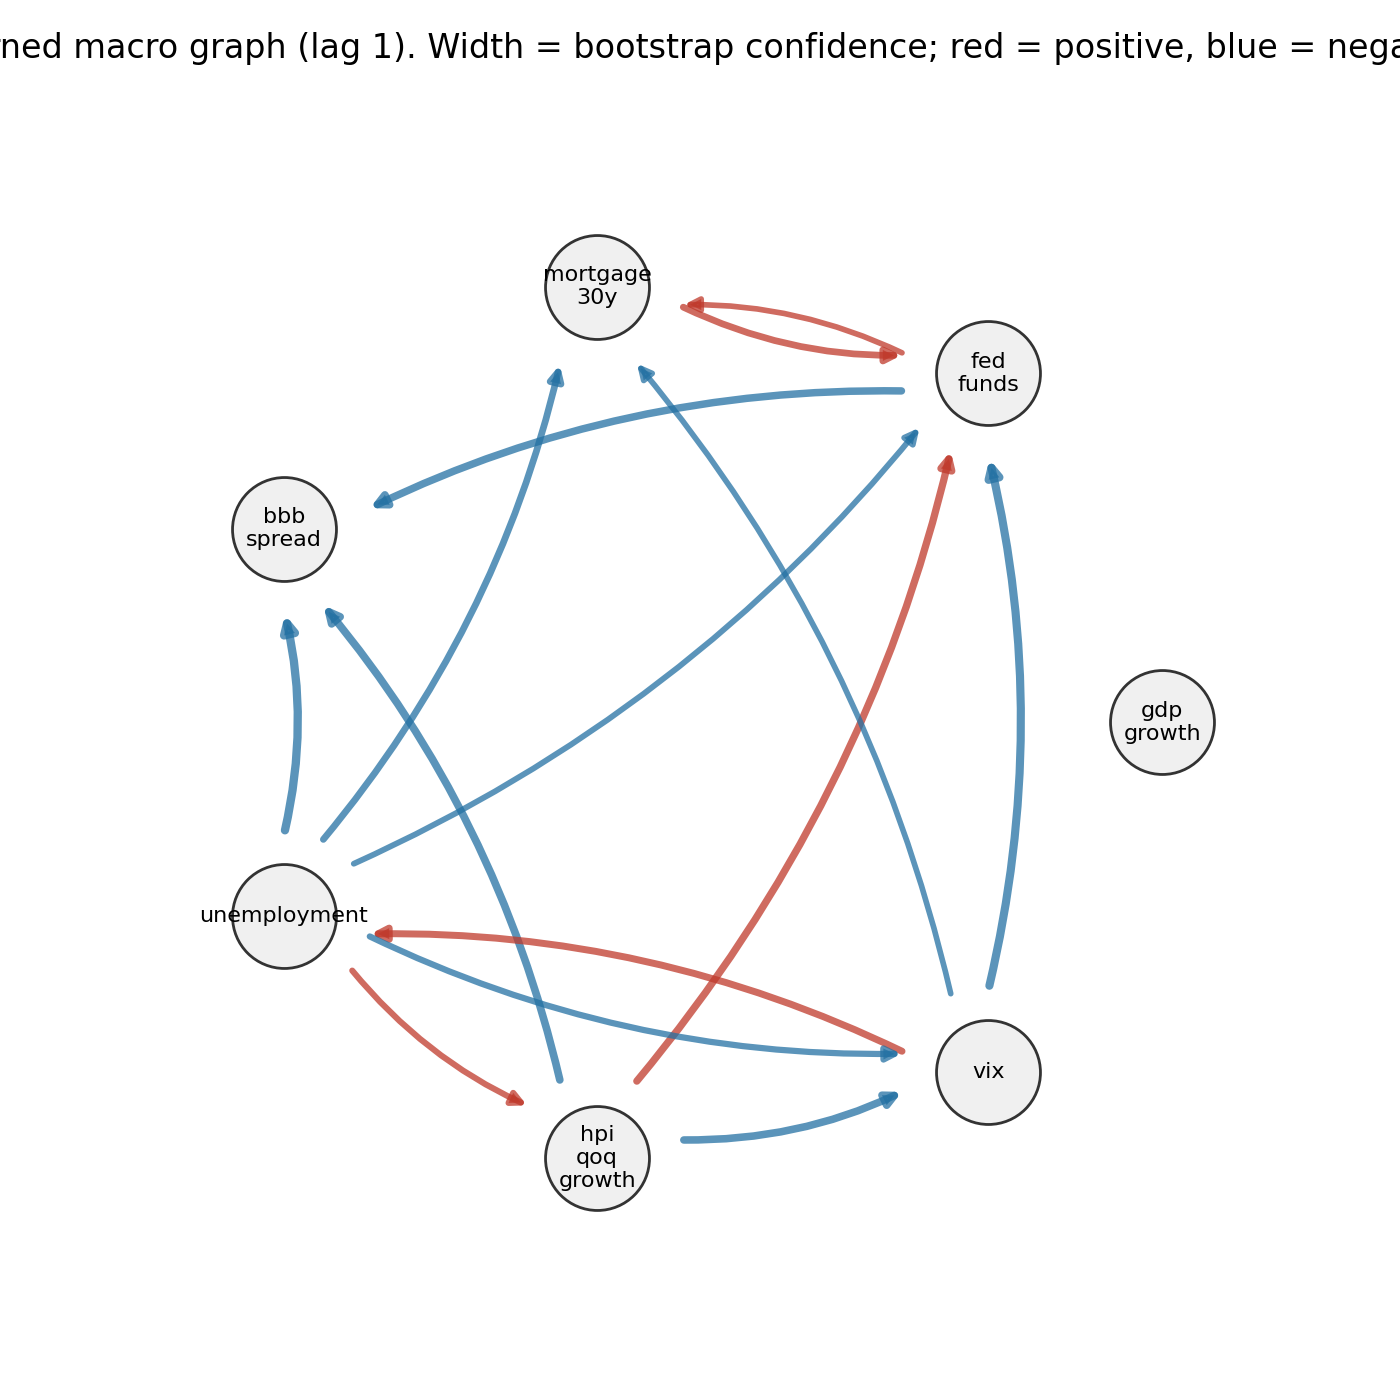

In [3]:
edges = edge_confidence(history, n_boot=100, seed=7)
cross = edges[edges["parent"] != edges["target"]]
display(cross.head(12))

edge_dir = RESULTS / "scengen" / "envelope_ladder"; edge_dir.mkdir(parents=True, exist_ok=True)
edges.to_csv(edge_dir / "edge_confidence.csv", index=False)
from multistate.scengen.plots import plot_graph
fig_dir = RESULTS / "scengen" / "figures"; fig_dir.mkdir(parents=True, exist_ok=True)
plot_graph(edge_dir / "edge_confidence.csv", fig_dir)
display(Image(str(fig_dir / "fig_graph.png"), width=560))

## One path from each contender

Same jump-off (the last observed quarter), one sampled future each. The floor
wanders, the VAR is smooth, the graph generator holds economic shape, the
Suppes event-cascade is spiky — the visual version of the exam results in 03.

In [ ]:
suite = default_generator_suite()
suite["suppes"] = SuppesPathGenerator()
show = ["delta_bootstrap", "var_gaussian", "graph_block", "suppes"]
jumpoff = history[FEATURES].iloc[-1].to_numpy(dtype=float)
feature = "unemployment"; fi = FEATURES.index(feature)

plt.figure(figsize=(8, 3.6))
tail = history[feature].tail(12)
plt.plot(range(-len(tail) + 1, 1), tail.to_numpy(), color="black", lw=2, label="history")
colors = {"delta_bootstrap": "#999999", "var_gaussian": "#1f77b4",
          "graph_block": "#843c0c", "suppes": "#7f7f7f"}
for name in show:
    generator = suite[name]; generator.fit(history)
    path = generator.sample(1, 12, np.random.default_rng(7), jumpoff=jumpoff)[0, :, fi]
    plt.plot(range(1, 13), path, marker=".", label=name, color=colors[name])
plt.axvline(0, color="#cccccc", lw=1); plt.xlabel("quarters (0 = jump-off)")
plt.ylabel(feature); plt.legend(fontsize=8); plt.title("One sampled future per generator")
plt.tight_layout(); plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_10208\3902469176.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()


**Takeaway.** The generator is auditable (every edge printable, signed,
confidence-scored), honest about information (inputs known at the jump-off only),
and sufficient (it wins the exam in 03). Simplicity is load-bearing.